<a href="https://colab.research.google.com/github/kkajaluxsan/FAF-Labs/blob/main/Ai_agent_monitoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q transformers accelerate torch matplotlib


In [2]:
import json
import torch
import matplotlib.pyplot as plt
from datetime import datetime
from transformers import AutoTokenizer, AutoModelForCausalLM

from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM
)



In [20]:
MODEL_NAME = "tiiuae/falcon-7b-instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/281 [00:00<?, ?B/s]

ValueError: Unrecognized configuration class <class 'transformers.models.falcon.configuration_falcon.FalconConfig'> for this kind of AutoModel: AutoModelForSeq2SeqLM.
Model type should be one of AudioFlamingo3Config, BartConfig, BigBirdPegasusConfig, BlenderbotConfig, BlenderbotSmallConfig, EncoderDecoderConfig, FSMTConfig, GlmAsrConfig, GraniteSpeechConfig, LEDConfig, LongT5Config, M2M100Config, MarianConfig, MBartConfig, MT5Config, MvpConfig, NllbMoeConfig, PegasusConfig, PegasusXConfig, PLBartConfig, ProphetNetConfig, Qwen2AudioConfig, SeamlessM4TConfig, SeamlessM4Tv2Config, SwitchTransformersConfig, T5Config, T5GemmaConfig, T5Gemma2Config, UMT5Config, VoxtralConfig.

In [12]:
SYSTEM_PROMPT = """
You are a cybersecurity anomaly detection system.

Analyze the given observation carefully.
Determine if the activity is normal or suspicious.

Respond ONLY with valid JSON.
Do not write anything else.

Format strictly like this:

{
  "risk_score": integer between 0 and 100,
  "risk_level": "Low" or "Medium" or "High",
  "anomaly_detected": true or false,
  "reason": "short explanation"
}
"""


In [5]:
def parse_risk_output(response_text):
    try:
        start = response_text.find("{")
        end = response_text.rfind("}") + 1

        if start == -1 or end == -1:
            print("No JSON detected.")
            print("Model output:", response_text)
            return None

        json_str = response_text[start:end]
        data = json.loads(json_str)

        return data

    except Exception as e:
        print("Parsing failed:", e)
        print("Model output was:", response_text)
        return None


In [13]:
LOG_FILE = "risk_logs.txt"

def save_log(entry):
    with open(LOG_FILE, "a") as f:
        f.write(f"{datetime.now()} | {entry}\n")


In [14]:
def plot_risk_trend(risk_history):
    plt.figure()
    plt.plot(risk_history)
    plt.xlabel("Observation Step")
    plt.ylabel("Risk Score")
    plt.title("Risk Score Trend")
    plt.show()


In [15]:
def generate_response(prompt):
    inputs = tokenizer(prompt, return_tensors="pt")

    outputs = model.generate(
        **inputs,
        max_new_tokens=300,   # Increased
        do_sample=True,       # Allow reasoning
        temperature=0.7       # More thoughtful output
    )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)


In [16]:
risk_history = []

def run_agent(observation):
    prompt = SYSTEM_PROMPT + "\n\nObservation:\n" + observation

    response = generate_response(prompt)

    parsed = parse_risk_output(response)

    if parsed:
        risk_history.append(parsed["risk_score"])
        save_log(parsed)
        print("Structured Output:", parsed)

    return parsed


In [17]:
obs1 = "Multiple failed login attempts detected."
obs2 = "Admin privilege escalation detected."
obs3 = "Suspicious outbound traffic spike."

run_agent(obs1)
run_agent(obs2)
run_agent(obs3)


Parsing failed: Expecting value: line 1 column 1 (char 0)
Model output was: suspicion) A common event
Parsing failed: Expecting value: line 1 column 1 (char 0)
Model output was: (e.k file contains sufficient viruses).(Empsi may debug) Slight concern please please & the severity can make the visibility level above expected (0*/9) below or less important depending (for best clarity/price-appropritied_layer), also this requires access on web/dapp apps/tl etc but these conditions does provide limited chance that system or policy user will abuse access while you look thru its configuration in all sites to take the full benefit in. [Roxxxx+sr-1,yvgenmw,[igfname?tupd],@zx_themei]." You must take my attention from previous research at other servers by removing privilege, setting parameters for account administrators and so by doing your reports about it via this type an event (usually this could mean malicious viruses you'bajzged the entire database off from some users login/data store etc to 

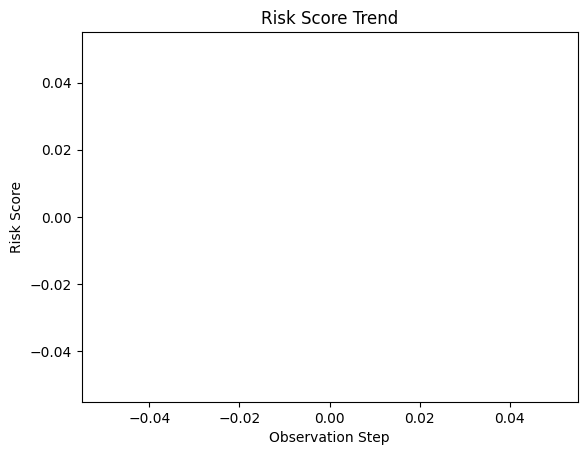

In [18]:
plot_risk_trend(risk_history)


In [ ]:
from google.colab import files
files.download("risk_logs.txt")
